In [1]:
import torch
import matplotlib.pyplot as plt
from torch import optim, distributions, nn
from tqdm.notebook import tqdm
import gpzoo
from gpzoo.kernels import NSF_RBF, batched_RBF, batched_MGGP_RBF
from gpzoo.gp import GaussianPrior, SVGP, MGGP_VNNGP, MGGP_WSVGP
from gpzoo.likelihoods import PNMF, NSF2, Hybrid_NSF2, Hybrid_NSF_Exact
from gpzoo.utilities import whitened_KL, train_hybrid, train_hybrid_batched, anndata_to_train_val, rescale_spatial_coords, add_jitter, scanpy_sizefactors, init_softplus
import squidpy as sq
import numpy as np
from sklearn.decomposition import NMF
import scanpy as sc
import random

from gpzoo.utilities import regularized_nmf, dims_autocorr
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import pickle
from sklearn.cluster import KMeans

import matplotlib.patheffects as path_effects

import pandas as pd

import anndata as ad
import gc

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [56]:
def plot_factors(factors, X, moran_idx=None, ax=None, size=7, alpha=0.8, s=0.1, names=None, vmin=None, vmax=None, cmap='turbo'):
    # If vmin/vmax not provided, infer from percentiles
    if vmin is None:
        vmin = np.percentile(factors, 1)
    if vmax is None:
        vmax = np.percentile(factors, 99)

    if moran_idx is not None:
        factors = factors[moran_idx]
        if names is not None:
            names = names[moran_idx]

    L = len(factors)

    if ax is None:
        fig, ax = plt.subplots(2, 6, figsize=(size*6, size*2), tight_layout=True)

    for i in range(L):
        curr_ax = ax[i // 6, i % 6]

        curr_ax.scatter(
            X[:, 0], X[:, 1],
            c=factors[i],
            vmin=vmin,
            vmax=vmax,
            alpha=alpha,
            cmap=cmap,
            s=s
        )

        curr_ax.invert_yaxis()

        if names is not None:
            curr_ax.set_title(
                names[i],
                x=0.03, y=0.88,
                fontsize="small",
                color="white",
                ha="left", va="top"
            )

        curr_ax.set_xticks([])
        curr_ax.set_yticks([])
        curr_ax.set_facecolor('xkcd:gray')


In [6]:
ad_path = '/gladstone/engelhardt/lab/lchumpitaz/datasets/liver/adata_healthy_diseased_merfish.h5ad'


In [7]:
adata = ad.read_h5ad(ad_path)


In [8]:
X = adata.obsm['X_spatial']

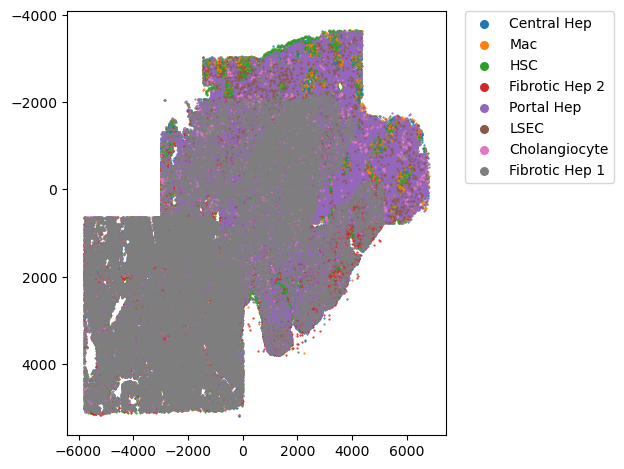

In [13]:
for class_label in adata.obs.Cell_Type_final.unique():
    idx = adata.obs.Cell_Type_final == class_label
    plt.scatter(X[idx][:, 0], X[idx][:, 1], s=0.3, label=class_label)

plt.gca().invert_yaxis()

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    ncol=(len(adata.obs.Cell_Type_final.unique()) + 9) // 10,
    markerscale=10  # <-- Increase this to make legend markers larger
)

plt.tight_layout()
plt.show()


In [15]:
adata.obs.sample_id.unique()

['AM048', 'AM061', 'AM042', 'AM031', 'AM062', 'AM072']
Categories (6, object): ['AM031', 'AM042', 'AM048', 'AM061', 'AM062', 'AM072']

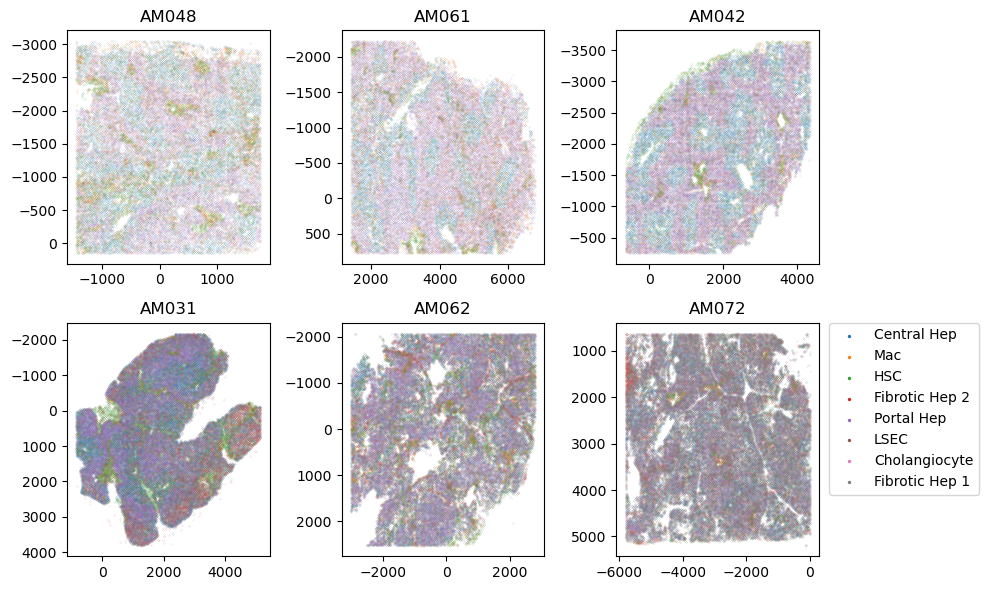

In [24]:

plt.figure(figsize=(10, 6))
for i, sample in enumerate(adata.obs.sample_id.unique()):
    plt.subplot(2, 3, i+1)

    for class_label in adata.obs.Cell_Type_final.unique():
        idx = (adata.obs.Cell_Type_final == class_label) & (adata.obs.sample_id == sample)
        plt.scatter(X[idx][:, 0], X[idx][:, 1], s=0.005, label=class_label)
        plt.title(sample)
    
    plt.gca().invert_yaxis()

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    ncol=(len(adata.obs.Cell_Type_final.unique()) + 9) // 10,
    markerscale=20  # <-- Increase this to make legend markers larger
)

plt.tight_layout()
plt.show()


In [25]:
Y = adata.raw.X.T


In [26]:
Y.shape

(317, 309808)

In [27]:
Y = adata.raw.X.T
V = scanpy_sizefactors(Y.T)

In [29]:
X = torch.tensor(X).type(torch.float)
Y = torch.tensor(Y).type(torch.float)
groupsX = torch.tensor(adata.obs.Cell_Type_final.values.codes).type(torch.LongTensor)
n_groups = len(adata.obs.Cell_Type_final.values.categories)

/tmp/ipykernel_1233976/4077536690.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X).type(torch.float)
/tmp/ipykernel_1233976/4077536690.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y).type(torch.float)


In [30]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=1)

In [31]:
D, N = Y.shape

In [51]:
def make_model(D, N, n_groups, L=12):
    M = N
    K=50
    
    Z = nn.Parameter(torch.tensor(X[:N]).type(torch.float), requires_grad=False)
    groupsZ = nn.Parameter(torch.tensor(groupsX[:N]).type(torch.LongTensor), requires_grad=False)
    kernel = batched_MGGP_RBF(sigma=1.0, lengthscale=100.0, group_diff_param=10.0, n_groups=n_groups)
    gp = MGGP_VNNGP(kernel, M=M, n_groups=n_groups, jitter=1e-5, K=K)
    mu = torch.randn(L, M)
    gp.mu = nn.Parameter(mu)
    Lu = 1e-2*torch.randn(L, M, K)
    gp.Lu = nn.Parameter(Lu.clone().detach())
    
    gp.Z = Z
    gp.groupsZ = groupsZ
    model = NSF2(gp, Y, L=L)
    W = torch.randn(D, L) 
    model.W = nn.Parameter(W)
    model.V = nn.Parameter(torch.squeeze(torch.tensor(init_softplus(V[:N])).type(torch.float)))

    return model



In [44]:
model = make_model(D, N, L=12)

/tmp/ipykernel_1233976/1438452480.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
/tmp/ipykernel_1233976/1438452480.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  groupsZ = nn.Parameter(torch.tensor(groupsX).type(torch.LongTensor), requires_grad=False)


In [52]:
model_healthy = make_model(D=317, N=90408, n_groups=9, L=12)

/tmp/ipykernel_1233976/611177252.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z = nn.Parameter(torch.tensor(X[:N]).type(torch.float), requires_grad=False)
/tmp/ipykernel_1233976/611177252.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  groupsZ = nn.Parameter(torch.tensor(groupsX[:N]).type(torch.LongTensor), requires_grad=False)


In [53]:
model_healthy.load_state_dict(torch.load('../models/liver_full_healthy_vnngp_mggp_random_init.pth'))

<All keys matched successfully>

In [54]:
model_healthy.cpu()
model_healthy.prior.K = 50

knn_idx = model_healthy.prior.calculate_knn(X)[:, :-1]
model_healthy.prior.knn_idx = knn_idx
knn_idz = model_healthy.prior.calculate_knn(model_healthy.prior.Z)[:, 1:]
model_healthy.prior.knn_idz = knn_idz


qF, _, _ = model_healthy.prior.forward(X=X, groupsX=groupsX, verbose=True)
mean = torch.exp(qF.mean).detach().numpy()
scale = qF.scale.detach().numpy()

→ Computing kernels
→kernels computed
applying constraints
done with constraints
adding jitter to Kzz
done with jitter
computing little Lu
Lu_knn shape: torch.Size([12, 309808, 50, 50])
Lu.shape: torch.Size([12, 309808, 50, 50])
Reshaped mu: torch.Size([12, 309808, 50])
Reshaped Lu: torch.Size([12, 309808, 50, 50])
Reshaped Kzx: torch.Size([309808, 50, 1])
Reshaped Kzz: torch.Size([309808, 50, 50])
Reshaped Kxx: torch.Size([309808, 1])
→ Cholesky(Kzz)
→ Solving for W
W shape: torch.Size([309808, 1, 50])
Lu lower_cholesky: tensor(True)
mu shape: torch.Size([12, 309808, 50])
Lu shape: torch.Size([12, 309808, 50, 50])
L shape: torch.Size([309808, 50, 50])
Lu lower_cholesky: tensor(True)
→ Computing mean
→ Mean shape: torch.Size([12, 309808, 1])
→ Diagonal covariance
cov_diag shape: torch.Size([309808, 1])
cov_diag shape: torch.Size([309808, 1])
cov_diag shape: torch.Size([12, 309808, 1])


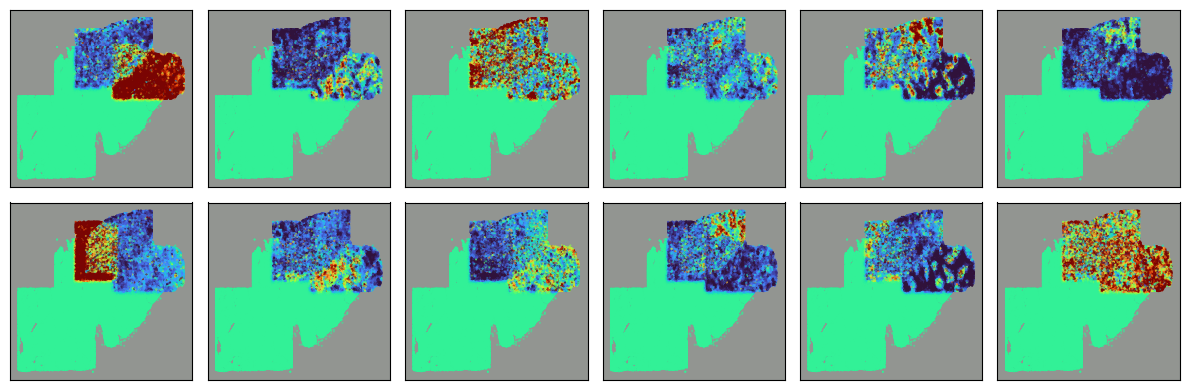

In [57]:

vmin=np.percentile(mean, 5)
vmax=np.percentile(mean, 95)
plot_factors(mean, X, moran_idx=None, ax=None, size=2, s=0.1, alpha=0.9, vmin=vmin, vmax=vmax)


In [64]:
with torch.no_grad():
    model.prior.mu[:, :M] = qF.mean
    model.W[:, :] = model_healthy.W

In [68]:
torch.save(model.state_dict(), '../models/liver_full_desease_vnngp_mggp_random_init.pth')